In [1]:
from jax import jit, random, vmap
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import config
import jax
import sys
from functools import partial

sys.path.append("../src")

jax.config.update("jax_platform_name", "cpu")

config.update("jax_enable_x64", True)

In [2]:
from configuration.rte2d_settings_ex5_oerfm2 import get_config
from constraints.continuous2d_oe_2 import (
    OddEvenDecompositionPointwiseBoundaryConstraint2D as BC,
    OddEvenDecompositionPointwiseInteriorConstraint2D as EQ,
)
from geometry.meshxd_ds import UniformMeshXYV
from modules.generator_2_copy import Sample2D
from modules.solution_2_copy import (
    OddEvenDecompositionAverage2D,
    OddEvenDecompositionConstructor2D,
)
from solver.least_square import solve
from utils.integrate import leggauss

In [3]:
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
strides = rte_config.mesh["strides"]
kn = rte_config.model.knudsen_number
coeff_fns = rte_config.model.coeff
source_fn = rte_config.model.source
Jn = rte_config.model.Jn
num_unknowns = rte_config.model.num_unknowns["j/r"]
scale = rte_config.model.scale
activation = rte_config.model.activation
regularizer = rte_config.model.regularizer
mode = rte_config.model.sample_mode
collocation_sizes = rte_config.model.collocation_sizes
bdy_value = rte_config.model.bdy_cond
key_num = rte_config.model.random_seed
rng_key = random.key(key_num)
num_quads = rte_config.model.num_quads
mesh_j = UniformMeshXYV(domain=domain, strides=strides)
mesh_r = UniformMeshXYV(domain=domain, strides=strides)

In [4]:
rte = EQ(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    num_quads=num_quads,
    kn=kn,
    activation=activation,
    coeff_fns=coeff_fns,
)
bc = BC(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
)

In [5]:
dummy_x, dummy_y, dummy_theta = jnp.split(jnp.array([-0.2, -1.0, 0.2]), 3, axis=0)
params = {}
# eq_instance = rte.apply(params, dummy_x, dummy_y, dummy_theta)
# bc_instance = bc.apply(params, dummy_x, dummy_y, dummy_theta)

In [6]:
# eq_instance.shape, bc_instance.shape

In [7]:
def eq_fn(x, y, theta):
    return partial(rte.apply, params)(x, y, theta)


def bc_fn(x, y, theta):
    return partial(bc.apply, params)(x, y, theta)


def rhs_fn(x, y, theta):
    quadratures = leggauss(num_quads, (0, jnp.pi / 2))
    pts, ws = quadratures

    def q_sym1(x, y, theta):
        return 0.5 * (
            source_fn(x, y, theta)
            + source_fn(x, y, theta + jnp.pi)
            + source_fn(x, y, -theta)
            + source_fn(x, y, -theta + jnp.pi)
        )

    def q_sym2(x, y, theta):
        return 0.5 * (
            source_fn(x, y, theta)
            + source_fn(x, y, theta + jnp.pi)
            - source_fn(x, y, -theta)
            - source_fn(x, y, -theta + jnp.pi)
        )

    def q_asym1(x, y, theta):
        return 0.5 * (
            source_fn(x, y, theta)
            - source_fn(x, y, theta + jnp.pi)
            + source_fn(x, y, -theta)
            - source_fn(x, y, -theta + jnp.pi)
        )

    def q_asym2(x, y, theta):
        return 0.5 * (
            source_fn(x, y, theta)
            - source_fn(x, y, theta + jnp.pi)
            - source_fn(x, y, -theta)
            + source_fn(x, y, -theta + jnp.pi)
        )

    weighted_sum1 = vmap(q_sym1, [None, None, 0])(x, y, pts) * ws
    avg_q1 = jnp.sum(weighted_sum1) / jnp.pi * 2

    rhs = jnp.stack(
        [
            avg_q1.squeeze(),
            kn**2 * (q_sym1(x, y, theta) - avg_q1).squeeze(),
            kn * q_asym1(x, y, theta).squeeze(),
            kn**2 * q_sym2(x, y, theta).squeeze(),
            kn * q_asym2(x, y, theta).squeeze(),
        ],
        axis=0,
    )
    return rhs


vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = (
    jit(vmap(eq_fn)),
    jit(vmap(bc_fn)),
    jit(vmap(rhs_fn)),
)

In [8]:
sampler = Sample2D(domain=domain, collocation_sizes=collocation_sizes, mode=mode)
pts_int, pts_left, pts_right, pts_lower, pts_upper = (
    sampler.pts_int,
    sampler.pts_left,
    sampler.pts_right,
    sampler.pts_lower,
    sampler.pts_upper,
)

In [9]:
# Evaluate the functions
bc_left, bc_right, bc_lower, bc_upper = (
    vmap_bc_fn(*pts_left),
    vmap_bc_fn(*pts_right),
    vmap_bc_fn(*pts_lower),
    vmap_bc_fn(*pts_upper),
)
print(
    f"bc_left.shape: {bc_left.shape}, bc_right.shape: {bc_right.shape}, bc_lower.shape: {bc_lower.shape}, bc_upper.shape: {bc_upper.shape}"
)

bc_left.shape: (2048, 2, 1024), bc_right.shape: (2048, 2, 1024), bc_lower.shape: (2048, 2, 1024), bc_upper.shape: (2048, 2, 1024)


In [10]:
eq_int = vmap_eq_fn(*pts_int)
print(f"eq_int.shape: {eq_int.shape}")  # ((Nx-2) * (Ny-2) * (Ntheta-2),3,32)

eq_int.shape: (12600, 5, 1024)


In [11]:
x_int, y_int, theta_int = pts_int
pts_int = x_int.squeeze(), y_int.squeeze(), theta_int.squeeze()
rhs_int = vmap_rhs_fn(*pts_int)
print(f"rhs_int.shape: {rhs_int.shape}")

rhs_int.shape: (12600, 5)


In [12]:
# Save the data
matrix_A = np.concatenate(
    [
        bc_left.reshape(-1, num_unknowns * 2),
        bc_right.reshape(-1, num_unknowns * 2),
        bc_lower.reshape(-1, num_unknowns * 2),
        bc_upper.reshape(-1, num_unknowns * 2),
        eq_int.reshape(-1, num_unknowns * 2),
    ],
    axis=0,
)

vector_b = np.zeros((matrix_A.shape[0], 1))
bdy_size_x, bdy_size_y, bdy_size_theta = collocation_sizes["boundary"]
vector_b[: 2 * bdy_size_y * bdy_size_theta : 2, 0] = (
    2 * bdy_value["f_l"](pts_left[1]).squeeze()
)
vector_b[
    2 * bdy_size_y * bdy_size_theta : 4 * bdy_size_y * bdy_size_theta : 2,
    0,
] = 2 * bdy_value["f_r"](pts_right[1]).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta : 4 * bdy_size_y * bdy_size_theta
    + 2 * bdy_size_x * bdy_size_theta : 2,
    0,
] = 2 * bdy_value["f_b"](pts_lower[0]).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta + 2 * bdy_size_x * bdy_size_theta : 4
    * bdy_size_y
    * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta : 2,
    0,
] = 2 * bdy_value["f_t"](pts_upper[0]).squeeze()

vector_b[
    4 * bdy_size_y * bdy_size_theta + 4 * bdy_size_x * bdy_size_theta :,
    0,
] = rhs_int.reshape(-1)

print(f"Matrix A: {matrix_A.shape}, Vector b: {vector_b.shape}")

Matrix A: (79384, 1024), Vector b: (79384, 1)


In [13]:
print("Matrix A 内存 %.2f MB" % (matrix_A.nbytes / 1024**2))
print("Vector b 内存 %.2f MB" % (vector_b.nbytes / 1024**2))

num_zero = np.sum(matrix_A == 0).item()
total = matrix_A.size
sparsity = num_zero / total
print(f"A的稀疏度 = {sparsity:.2%} (零元素比例)")
num_zero = np.sum(vector_b == 0).item()
total = vector_b.size
sparsity = num_zero / total
print(f"b的稀疏度 = {sparsity:.2%} (零元素比例)")
condition_number = np.linalg.cond(matrix_A)
print(f"A的条件数 = {condition_number:.2e}")

Matrix A 内存 620.19 MB
Vector b 内存 0.61 MB
A的稀疏度 = 7.94% (零元素比例)
b的稀疏度 = 68.26% (零元素比例)
A的条件数 = 1.20e+08


In [14]:
vector_U = solve(matrix_A, vector_b, c=regularizer)
print(f"Vector U: {vector_U.shape}")

Vector U: (1024, 1)


In [15]:
error = matrix_A @ vector_U - vector_b
(
    np.abs(error).max(),
    np.abs(error).mean(),
)

(0.4464263400573145, 0.015165196732159702)

In [16]:
n_bc = bc_left.shape[0] * 2
(
    np.abs(error)[n_bc * 0 : n_bc * 1].mean(),
    np.abs(error)[n_bc * 1 : n_bc * 2].mean(),
    np.abs(error)[n_bc * 2 : n_bc * 3].mean(),
    np.abs(error)[n_bc * 3 : n_bc * 4].mean(),
    np.abs(error)[n_bc * 4 :].mean(),
)

(0.023018720802506137,
 0.02785949581210545,
 0.02112563551691836,
 0.028649404036359627,
 0.012565051430509367)

In [17]:
# data = np.load("../src/data/weights.npz")
# vector_U = data["coefficients"]

In [18]:
coefficients = jnp.array(vector_U).reshape(
    num_unknowns * 2,
)
constructor = OddEvenDecompositionConstructor2D(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
    coefficients=coefficients,
)
average = OddEvenDecompositionAverage2D(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
    coefficients=coefficients,
)

In [19]:
def approx_fn(x, y, theta):
    return partial(constructor.apply, params)(x, y, theta)

In [20]:
def aver_fn(x, y):
    quadratures = leggauss(num_quads, (0, jnp.pi / 2))
    pts, ws = quadratures
    weighted_sum = vmap(approx_fn, [None, None, 0])(x, y, pts) @ ws
    return weighted_sum / jnp.pi * 2

In [21]:
# vmap_approx_fn = vmap(approx_fn)
approx_fn = jit(approx_fn)

In [22]:
dummy_z = jnp.array([0, 0, 0])
dummy_x, dummy_y, dummy_v = jnp.split(dummy_z, 3, axis=-1)
print(
    f"f({dummy_z}) = {approx_fn(dummy_x, dummy_y, dummy_v)}"
)  # f([0. 0. 0.]) = 1.000002714641632

f([0 0 0]) = 0.7061894017956887


In [23]:
def average_fn(x, y):
    quadratures = leggauss(num_quads, (0, jnp.pi / 2))
    pts, ws = quadratures
    weighted_sum = vmap(average.apply, [None, None, None, 0])(params, x, y, pts) @ ws
    return weighted_sum / jnp.pi * 2.0

In [24]:
data = np.load(f"../src/data/rte2d_ex5_ref_{kn:.1e}.npz")
print("Keys in data:", data.keys())

Keys in data: KeysView(NpzFile '../src/data/rte2d_ex5_ref_1.0e+00.npz' with keys: mesh_x, mesh_y, rho)


In [25]:
mesh_x, mesh_y = data["mesh_x"], data["mesh_y"]
f_ex = data["rho"]

X, Y = np.meshgrid(mesh_x, mesh_y)
f_approx = vmap(aver_fn, [0, 0])(X.reshape(-1, 1), Y.reshape(-1, 1)).reshape(X.shape)
f_app = vmap(average_fn, [0, 0])(X.reshape(-1, 1), Y.reshape(-1, 1)).reshape(X.shape)

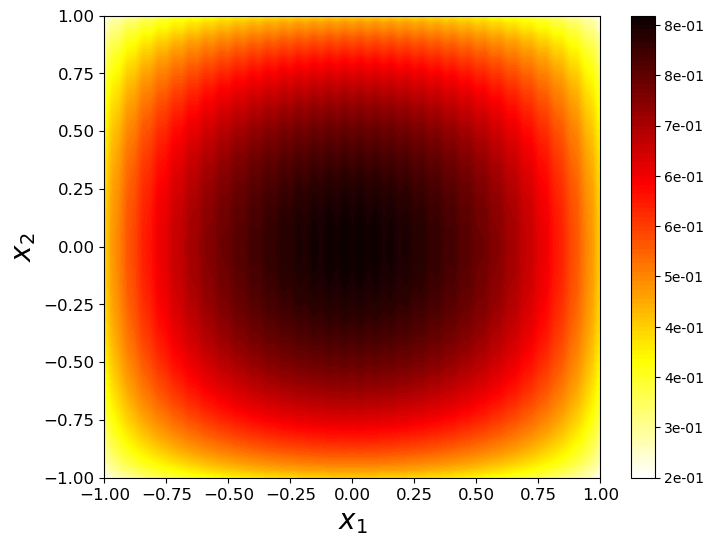

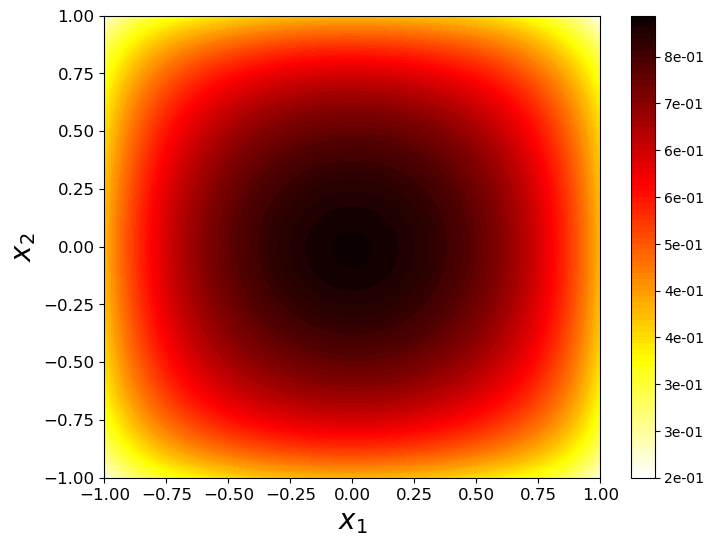

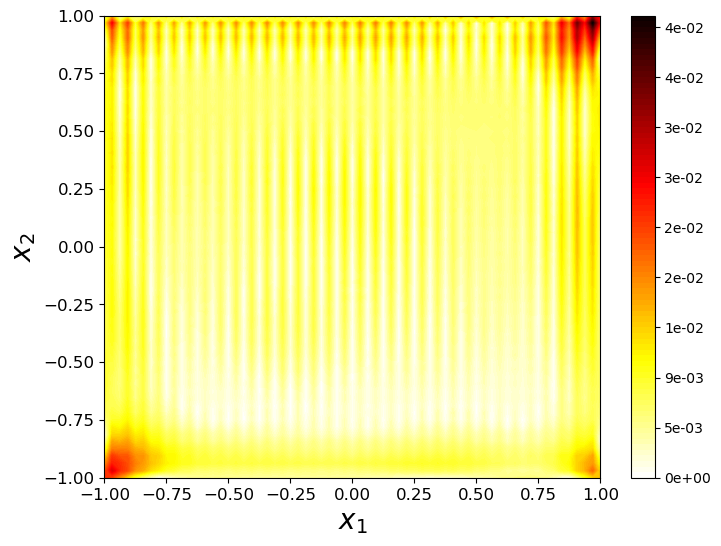

In [26]:
F, F_hat = f_ex, f_app

font_format = {"size": 20}

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, F, 100, cmap="hot_r")
# font size and type
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
# plt.title("Reference solution", font_format)

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, F_hat, 100, cmap="hot_r")
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
# plt.title("OE-APRFM solution", font_format)

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, np.abs(F - F_hat), 100, cmap="hot_r")
# plt.contourf(X, V, np.abs(F - F_hat), 100, cmap='Spectral_r')
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
# plt.title("Error", font_format)

# plt.savefig(f"./figures/aprfm2d_{kn:.1e}_contourf_ex4.png", dpi=300)
plt.show()
plt.close()

In [27]:
jnp.linalg.norm(F_hat - F) / jnp.linalg.norm(F)

Array(0.01148284, dtype=float64)

In [28]:
# from matplotlib import cm
# from mpl_toolkits.mplot3d.art3d import Line3DCollection


# def plot_3d(ax, X, Y, Z, cmap, norm):
#     X = np.asarray(X)
#     Y = np.asarray(Y)
#     Z = np.asarray(Z)

#     for i in range(X.shape[0]):
#         row_points = np.stack((X[i, :], Y[i, :], Z[i, :]), axis=1)
#         row_color = cmap(norm(np.mean(Z[i, :])))
#         row_line = Line3DCollection(
#             [row_points], colors=[row_color], linewidths=0.9, alpha=0.95
#         )
#         ax.add_collection3d(row_line)

#     for j in range(X.shape[1]):
#         col_points = np.stack((X[:, j], Y[:, j], Z[:, j]), axis=1)
#         col_color = cmap(norm(np.mean(Z[:, j])))
#         col_line = Line3DCollection(
#             [col_points], colors=[col_color], linewidths=0.9, alpha=0.95
#         )
#         ax.add_collection3d(col_line)

#     ax.set_xlim(X.min(), X.max())
#     ax.set_ylim(Y.min(), Y.max())
#     ax.set_zlim(Z.min(), Z.max())
#     ax.set_xlabel(r"$x_1$", fontsize=14, labelpad=8)
#     ax.set_ylabel(r"$x_2$", fontsize=14, labelpad=8)
#     ax.zaxis.set_rotate_label(False)
#     ax.set_zlabel(r"$\rho$", fontsize=14, labelpad=10, rotation=90)
#     ax.tick_params(axis="both", which="major", labelsize=10, pad=2)
#     ax.view_init(elev=26, azim=-128)
#     ax.set_box_aspect((1.0, 1.0, 0.62))
#     ax.xaxis.pane.set_alpha(0.05)
#     ax.yaxis.pane.set_alpha(0.05)
#     ax.zaxis.pane.set_alpha(0.05)
#     ax.grid(False)

#     mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
#     mappable.set_array([])
#     return mappable

In [29]:
# from matplotlib import cm
# from matplotlib import colors as mcolors

# rho = np.asarray(f_app)
# rho_ref_grid = np.asarray(f_ex)

# rel_error = np.linalg.norm(rho - rho_ref_grid) / np.linalg.norm(rho_ref_grid)
# print(f"relative error: {rel_error:.6e}")

# plt.rcParams.update({"font.size": 11, "axes.labelsize": 12})
# SAVE_FIG = False

# vmin = min(rho.min(), rho_ref_grid.min())
# vmax = max(rho.max(), rho_ref_grid.max())
# norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# # Figure 1: OE-APRFM
# fig = plt.figure(figsize=(8, 6), constrained_layout=True)
# ax = fig.add_subplot(111, projection="3d")
# mappable = plot_3d(
#     ax,
#     X[::3, ::3],
#     Y[::3, ::3],
#     rho[::3, ::3],
#     cmap=cm.viridis,
#     norm=norm,
# )
# cbar = fig.colorbar(mappable, ax=ax, shrink=0.82, pad=0.06, aspect=22)
# cbar.set_label(r"$\rho$", rotation=90, labelpad=8)
# if SAVE_FIG:
#     fig.savefig(
#         f"./rte2d_rho_colormesh_oeaprfm_{kn:.1e}.png", dpi=300, bbox_inches="tight"
#     )
# plt.show()
# plt.close(fig)

# # Figure 2: Reference
# fig = plt.figure(figsize=(8, 6), constrained_layout=True)
# ax = fig.add_subplot(111, projection="3d")
# mappable = plot_3d(
#     ax,
#     X[::3, ::3],
#     Y[::3, ::3],
#     rho_ref_grid[::3, ::3],
#     cmap=cm.viridis,
#     norm=norm,
# )
# cbar = fig.colorbar(mappable, ax=ax, shrink=0.82, pad=0.06, aspect=22)
# cbar.set_label(r"$\rho$", rotation=90, labelpad=8)
# if SAVE_FIG:
#     fig.savefig(
#         f"./rte2d_rho_colormesh_reference_{kn:.1e}.png", dpi=300, bbox_inches="tight"
#     )
# plt.show()
# plt.close(fig)

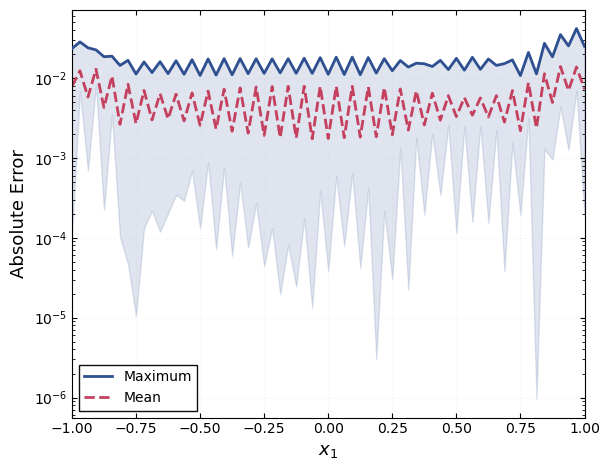

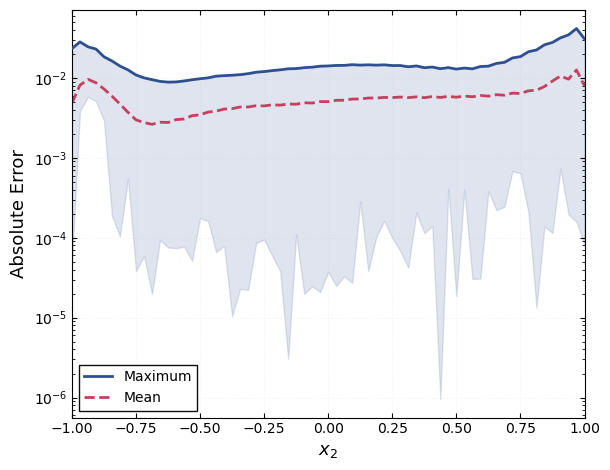

In [30]:
# ========== 2D Error Profiles: x1 / x2 / boundary-theta ==========
mesh_x_np = np.asarray(mesh_x)
mesh_y_np = np.asarray(mesh_y)
error = np.abs(np.asarray(F_hat) - np.asarray(F)).astype(float)
eps = 1e-16

colors = {
    "primary": "#2E5090",  # Deep blue
    "secondary": "#C4405E",  # Deep rose
    "tertiary": "#5D8AA8",  # Steel blue
    "quaternary": "#A8717A",  # Dusty rose
    "grid": "#CCCCCC",
    "light_blue": "#7BA3C4",
    "light_red": "#D17A8D",
}
# ---------- Figure 1: Error along x1 ----------
fig = plt.figure(figsize=(6.2, 4.8))
ax1 = fig.add_subplot(111)
error_max_x = np.nanmax(error, axis=0)
error_mean_x = np.nanmean(error, axis=0)
error_min_x = np.nanmin(error, axis=0)
ax1.semilogy(
    mesh_x_np,
    np.maximum(error_max_x, eps),
    "-",
    color=colors["primary"],
    linewidth=2,
    label="Maximum",
    zorder=3,
)
ax1.semilogy(
    mesh_x_np,
    np.maximum(error_mean_x, eps),
    "--",
    color=colors["secondary"],
    linewidth=2,
    label="Mean",
    zorder=2,
)
ax1.fill_between(
    mesh_x_np,
    np.maximum(error_min_x, eps),
    np.maximum(error_max_x, eps),
    alpha=0.15,
    color=colors["primary"],
    zorder=1,
)
ax1.set_xlabel(r"$x_1$", fontsize=13)
ax1.set_ylabel("Absolute Error", fontsize=13)
# ax1.set_title("Error along $x_1$", fontsize=13, pad=8)
ax1.legend(
    loc="best",
    frameon=True,
    framealpha=0.95,
    edgecolor="black",
    fancybox=False,
    shadow=False,
)
ax1.grid(True, alpha=0.25, linestyle=":", linewidth=0.8, color=colors["grid"])
ax1.tick_params(direction="in", which="both", top=True, right=True)
ax1.set_xlim([mesh_x_np[0], mesh_x_np[-1]])
plt.tight_layout()
plt.show()

# ---------- Figure 2: Error along x2 ----------
fig = plt.figure(figsize=(6.2, 4.8))
ax2 = fig.add_subplot(111)
error_max_y = np.nanmax(error, axis=1)
error_mean_y = np.nanmean(error, axis=1)
error_min_y = np.nanmin(error, axis=1)
ax2.semilogy(
    mesh_y_np,
    np.maximum(error_max_y, eps),
    "-",
    color=colors["primary"],
    linewidth=2,
    label="Maximum",
    zorder=3,
)
ax2.semilogy(
    mesh_y_np,
    np.maximum(error_mean_y, eps),
    "--",
    color=colors["secondary"],
    linewidth=2,
    label="Mean",
    zorder=2,
)
ax2.fill_between(
    mesh_y_np,
    np.maximum(error_min_y, eps),
    np.maximum(error_max_y, eps),
    alpha=0.15,
    color=colors["primary"],
    zorder=1,
)
ax2.set_xlabel(r"$x_2$", fontsize=13)
ax2.set_ylabel("Absolute Error", fontsize=13)
# ax2.set_title("Error along $x_2$", fontsize=13, pad=8)
ax2.legend(
    loc="best",
    frameon=True,
    framealpha=0.95,
    edgecolor="black",
    fancybox=False,
    shadow=False,
)
ax2.grid(True, alpha=0.25, linestyle=":", linewidth=0.8, color=colors["grid"])
ax2.tick_params(direction="in", which="both", top=True, right=True)
ax2.set_xlim([mesh_y_np[0], mesh_y_np[-1]])
plt.tight_layout()
plt.show()